In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('Consumer_Complaints.xlsx', parse_dates=['Date submitted', 'Date received'])


      
print(df.head(10))       

   Complaint ID Submitted via Date submitted Date received State  \
0       4848023      Referral     2021-10-24    2021-10-27    NY   
1       3621464           Web     2020-04-24    2020-04-24    FL   
2       5818349           Web     2022-07-27    2022-07-27    CA   
3       7233015      Referral     2023-07-10    2023-07-11    CA   
4       5820224      Referral     2022-07-27    2022-07-28    VA   
5       6237961           Web     2022-11-23    2022-11-23    CA   
6       4348292           Web     2021-05-04    2021-05-04    TX   
7       4090544           Web     2021-01-24    2021-01-24    CA   
8       5337082           Web     2022-03-18    2022-03-18    TX   
9       6203657           Web     2022-11-14    2022-11-14    VA   

                                             Product  \
0                                           Mortgage   
1  Money transfer, virtual currency, or money ser...   
2  Credit reporting, credit repair services, or o...   
3                        Cr

In [3]:
print(df.shape)        
print(df.dtypes) 

(62516, 12)
Complaint ID                             int64
Submitted via                           object
Date submitted                  datetime64[ns]
Date received                   datetime64[ns]
State                                   object
Product                                 object
Sub-product                             object
Issue                                   object
Sub-issue                               object
Company public response                 object
Company response to consumer            object
Timely response?                        object
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [5]:
df.isnull().sum()

Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to consumer        0
Timely response?                 1494
dtype: int64

In [6]:
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_percent': (df.isnull().sum() / len(df) * 100).round(2)
})

In [7]:
print(null_summary[null_summary['null_count'] > 0])

                         null_count  null_percent
Sub-product                       7          0.01
Sub-issue                     10858         17.37
Company public response        2175          3.48
Timely response?               1494          2.39


In [8]:
df['Sub-issue'] = df['Sub-issue'].fillna('Not specified')
df['Sub-product'] = df['Sub-product'].fillna('Not specified')

In [9]:
df['Company public response'] = df['Company public response'].fillna('No public response')
df['Timely response?'] = df['Timely response?'].fillna('Unknown')

In [10]:
df['Complaint ID'] = df['Complaint ID'].astype(str)

In [11]:
print(df['Date submitted'].dtype)   
print(df['Date received'].dtype)

datetime64[ns]
datetime64[ns]


In [12]:
df['Days to receive'] = (df['Date received'] - df['Date submitted']).dt.days
print(df['Days to receive'].describe())

count    62516.000000
mean         1.224886
std          5.649298
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: Days to receive, dtype: float64


In [13]:
text_cols = ['Submitted via', 'State', 'Product', 'Sub-product',
             'Issue', 'Sub-issue', 'Company public response',
             'Company response to consumer', 'Timely response?']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [14]:
print(df['Submitted via'].unique())
print(df['Timely response?'].unique())

['Referral' 'Web' 'Phone' 'Postal Mail' 'Web Referral' 'Fax' 'Email']
['Yes' 'Unknown' 'No']


In [15]:
print(f"Duplicate Complaint IDs: {df.duplicated(subset='Complaint ID').sum()}")

Duplicate Complaint IDs: 0


In [16]:
df = df.drop_duplicates(subset='Complaint ID', keep='first')
print(f"Rows after dedup: {len(df)}")

Rows after dedup: 62516


In [17]:
error_dates = df[df['Date received'] < df['Date submitted']]
print(f"Rows with error date order: {len(error_dates)}")

Rows with error date order: 0


In [18]:
import datetime
today = datetime.date.today()
future_dates = df[df['Date submitted'].dt.date > today]
print(f"Future dates: {len(future_dates)}")

Future dates: 0


/var/folders/5_/8jskkpt95h755pnqhw7ssxyc0000gn/T/ipykernel_10041/4127313465.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


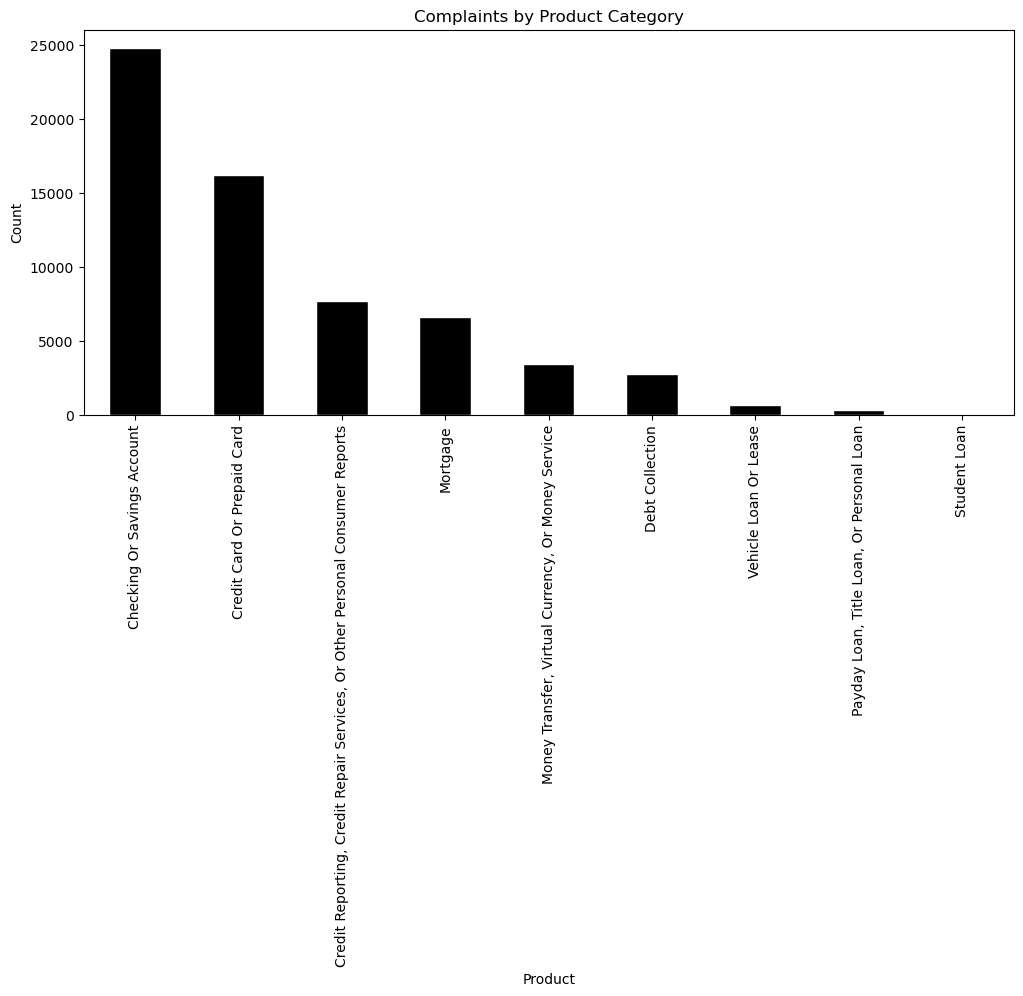

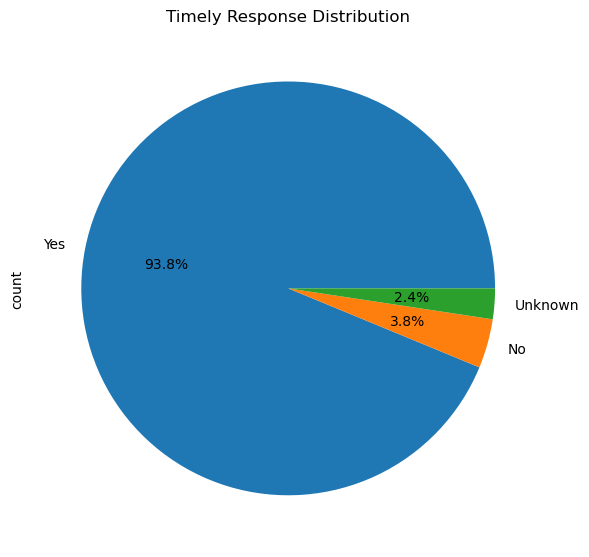

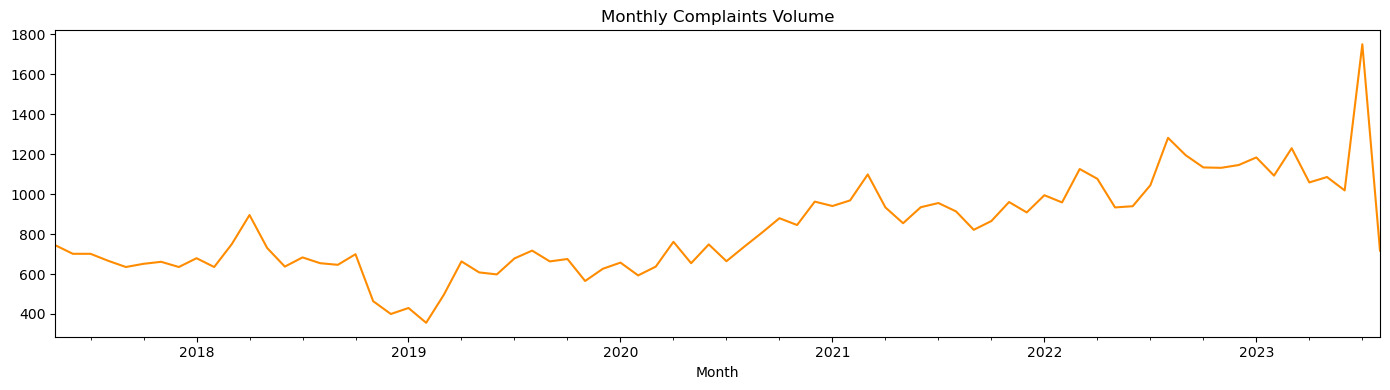

In [19]:
plt.figure(figsize=(12, 5))
df['Product'].value_counts().plot(kind='bar', color='black', edgecolor='white')
plt.title('Complaints by Product Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('complaints_by_product.png', dpi=150)
plt.show()


df['Timely response?'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Timely Response Distribution')
plt.tight_layout()
plt.savefig('timely_response.png', dpi=150)
plt.show()


df['Month'] = df['Date submitted'].dt.to_period('M')
monthly = df.groupby('Month').size()
monthly.plot(figsize=(14, 4), title='Monthly Complaints Volume', color='darkorange')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

In [20]:
df.to_csv('consumer_clean.csv', index=False)

In [21]:
df.to_excel('consumer_clean.xlsx', index=False)

In [22]:
print("Clean files saved successfully.")
print(f"Final shape: {df.shape}")

Clean files saved successfully.
Final shape: (62516, 14)


In [23]:
for col in df.select_dtypes(include='object').columns:
    blank_spaces = df[col].str.strip().eq('').sum()
    if blank_spaces > 0:
        print(f"{col}: {blank_spaces} blank spaces found")
    else:
        print(f"{col}: No blank spaces")

Complaint ID: No blank spaces
Submitted via: No blank spaces
State: No blank spaces
Product: No blank spaces
Sub-product: No blank spaces
Issue: No blank spaces
Sub-issue: No blank spaces
Company public response: No blank spaces
Company response to consumer: No blank spaces
Timely response?: No blank spaces
